# Synthetic CAN — Burak & Fiete (2009) exact reproduction

Direct translation of `gc_periodic.m` with the same trajectory generator,
same parameters, and same velocity-input formula.

**Key difference from previous attempts:**  
The Matlab code passes raw `dx, dy` displacements per step into the velocity input,
not a unit-direction vector.  `vel * cos(θ)` = `dx` and `vel * sin(θ)` = `dy`.
The trajectory uses internal units (enclosure radius = 200, max speed 0.25 per step)
that are calibrated to work with `alpha=1`.  Trying to map these to physical cm/s
breaks the calibration — so we reproduce the model in its own units.

**On the all-negative filter:**  
With `abar=1, alphabar=1.05` the net filter is exactly 0 at the origin and negative
everywhere else — no positive weights.  This is correct.  The bump is sustained by
uniform feedforward input (venvelope=1); the filter creates *differential* inhibition
that suppresses neurons outside the bump more than those inside it.

**On multiple bumps:**  
The sheet settles into a hexagonal crystal of ~(N/λ)² simultaneous bumps.  This is
the intended attractor state.  Each neuron fires when any bump passes its sheet
position, producing periodic hexagonal spatial fields.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['font.family'] = 'Arial'

fig_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_validations/'
rng = np.random.default_rng(42)

# ── Parameters — exact from gc_dynamics.m / gc_periodic.m ─────────────────────
N        = 128        # neurons per side  (paper: 2^7)
DT       = 0.5        # ms per step
TAU      = 5.0        # ms
LAMBDA   = 13         # blob spacing in neurons (Eq. 3)
BETA     = 3.0 / LAMBDA**2
ALPHABAR = 1.05
ABAR     = 1.0
WTPHASE  = 2          # shift in neurons
ALPHA    = 1.0        # velocity gain — paper value, calibrated to trajectory below
BIG      = 2 * N

# Trajectory parameters — exact from gc_periodic.m
N_TRAJ   = 100_000    # steps (50 s at 0.5 ms)
ENC_R    = 200        # enclosure radius in internal units

print(f'N={N}  λ={LAMBDA}  β={BETA:.5f}  αbar={ALPHABAR}  wtphase={WTPHASE}')
print(f'Trajectory: {N_TRAJ} steps in circular arena radius={ENC_R}')

N=128  λ=13  β=0.01775  αbar=1.05  wtphase=2
Trajectory: 100000 steps in circular arena radius=200


## 1. Trajectory — exact gc_periodic.m random walk

Trajectory: speed range 0.000 – 0.250 units/step
  mean speed = 0.126  (paper expects ~0.1 units/step)


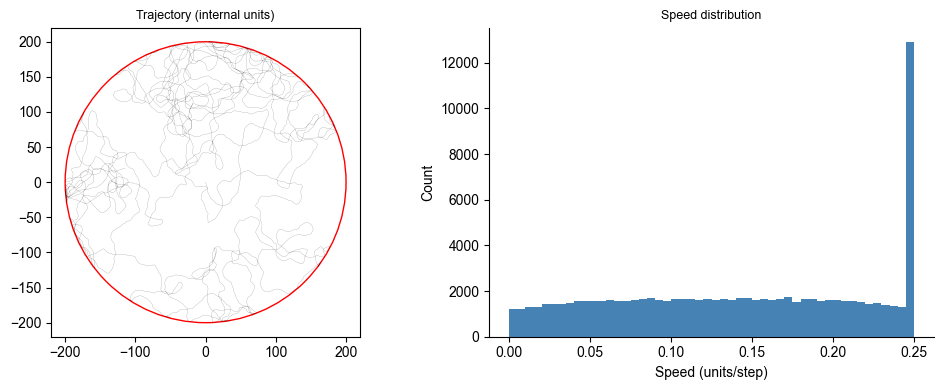

In [8]:
# ── Reproduce gc_periodic.m lines 24-55 exactly ───────────────────────────────
position_x  = np.zeros(N_TRAJ)
position_y  = np.zeros(N_TRAJ)
head_dir    = np.zeros(N_TRAJ)

position_x[0] = 0.0
position_y[0] = 0.0
head_dir[0]   = rng.random() * 2 * np.pi
temp_vel      = rng.random() / 2   # initial speed in (0, 0.5)

for i in range(1, N_TRAJ):
    # Acceleration: max ±0.2, normally distributed with σ=0.05
    temp_rand = float(np.clip(rng.normal(0, 0.05), -0.2, 0.2))
    temp_vel  = float(np.clip(temp_vel + temp_rand, 0.0, 0.25))

    # Wall avoidance: rotate until future position is inside the enclosure
    left_or_right = 1 if rng.random() < 0.5 else -1
    hd = head_dir[i-1]
    while True:
        fx = position_x[i-1] + np.cos(hd) * temp_vel
        fy = position_y[i-1] + np.sin(hd) * temp_vel
        if fx*fx + fy*fy <= ENC_R*ENC_R:
            break
        hd += left_or_right * np.pi / 100
    head_dir[i-1] = hd   # update (matches Matlab mutation of headDirection(i-1))

    position_x[i] = position_x[i-1] + np.cos(head_dir[i-1]) * temp_vel
    position_y[i] = position_y[i-1] + np.sin(head_dir[i-1]) * temp_vel
    head_dir[i]   = (head_dir[i-1] + (rng.random() - 0.5) / 5 * np.pi / 2) % (2*np.pi)

# Velocity magnitude per step (used as `vel` in Eq. 4)
dx_arr = np.diff(position_x, prepend=position_x[0])
dy_arr = np.diff(position_y, prepend=position_y[0])
vel_arr = np.sqrt(dx_arr**2 + dy_arr**2)

print(f'Trajectory: speed range {vel_arr.min():.3f} – {vel_arr.max():.3f} units/step')
print(f'  mean speed = {vel_arr.mean():.3f}  (paper expects ~0.1 units/step)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(position_x[::20], position_y[::20], 'k-', lw=0.2, alpha=0.4)
circle = plt.Circle((0, 0), ENC_R, fill=False, color='red', lw=1)
axes[0].add_patch(circle)
axes[0].set_aspect('equal'); axes[0].set_title('Trajectory (internal units)', fontsize=9)
axes[1].hist(vel_arr[vel_arr > 0], bins=50, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Speed (units/step)'); axes[1].set_ylabel('Count')
axes[1].set_title('Speed distribution', fontsize=9)
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Filter and FFTs

Filter: centre=0.000000  min=-0.01794  max=0.00000


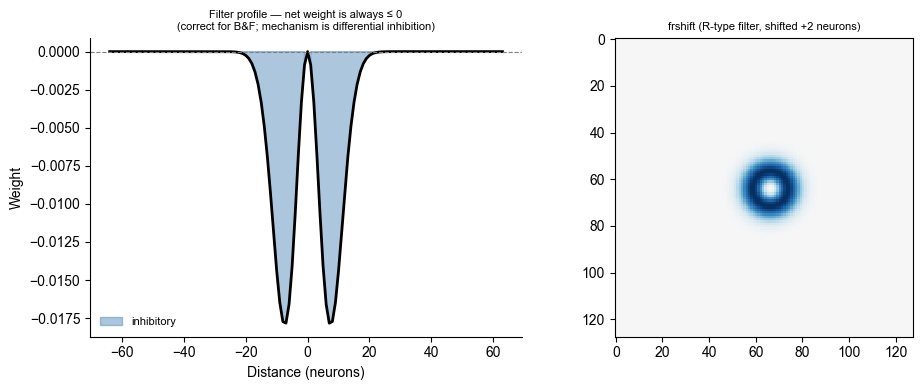

In [9]:
# ── Filter — gc_periodic.m lines 111-128 ─────────────────────────────────────
x    = np.arange(-N//2, N//2, dtype=float)
xbar = np.sqrt(BETA) * x
XBAR2 = xbar[:, None]**2 + xbar[None, :]**2
filt  = ABAR * np.exp(-ALPHABAR * XBAR2) - np.exp(-XBAR2)

# ── Shifted copies — gc_periodic.m lines 139-142 ─────────────────────────────
frshift = np.roll(filt,  WTPHASE, axis=1)
flshift = np.roll(filt, -WTPHASE, axis=1)
fdshift = np.roll(filt,  WTPHASE, axis=0)
fushift = np.roll(filt, -WTPHASE, axis=0)

# FFTs for aperiodic init (padded) — gc_periodic.m lines 144-147
ftu_big = np.fft.fft2(fushift, (BIG, BIG))
ftd_big = np.fft.fft2(fdshift, (BIG, BIG))
ftl_big = np.fft.fft2(flshift, (BIG, BIG))
ftr_big = np.fft.fft2(frshift, (BIG, BIG))

# FFTs for periodic simulation (fftshift centres filter at (0,0)) — lines 149-152
ftu_sm  = np.fft.fft2(np.fft.fftshift(fushift))
ftd_sm  = np.fft.fft2(np.fft.fftshift(fdshift))
ftl_sm  = np.fft.fft2(np.fft.fftshift(flshift))
ftr_sm  = np.fft.fft2(np.fft.fftshift(frshift))

# ── Neuron type matrices — gc_periodic.m lines 158-161 ────────────────────────
# typeL: (i%2, j%2) == (0,0);  typeU: (0,1);  typeD: (1,0);  typeR: (1,1)
ii   = np.arange(N) % 2
jj   = np.arange(N) % 2
tile = ii[:, None] * 2 + jj[None, :]
typeL = (tile == 0).astype(float)
typeU = (tile == 1).astype(float)
typeD = (tile == 2).astype(float)
typeR = (tile == 3).astype(float)

# ── Gaussian envelope — gc_periodic.m line 132 ────────────────────────────────
X_env, Y_env = np.meshgrid(x, x, indexing='ij')
venv_gauss   = np.exp(-4 * (X_env**2 + Y_env**2) / (N//2)**2)
venv_ones    = np.ones((N, N))

print(f'Filter: centre={filt[N//2,N//2]:.6f}  min={filt.min():.5f}  max={filt.max():.5f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(x, filt[N//2, :], 'k-', lw=2)
axes[0].axhline(0, color='grey', lw=0.8, ls='--')
axes[0].fill_between(x, filt[N//2,:], 0, where=filt[N//2,:]<0,
                      color='#3171ae', alpha=0.4, label='inhibitory')
axes[0].set_xlabel('Distance (neurons)'); axes[0].set_ylabel('Weight')
axes[0].set_title('Filter profile — net weight is always ≤ 0\n'
                   '(correct for B&F; mechanism is differential inhibition)', fontsize=8)
axes[0].legend(fontsize=8, frameon=False)
axes[0].spines[['top','right']].set_visible(False)

axes[1].imshow(frshift, cmap='RdBu_r',
               vmin=filt.min(), vmax=-filt.min(), interpolation='nearest')
axes[1].set_title(f'frshift (R-type filter, shifted +{WTPHASE} neurons)', fontsize=8)
plt.tight_layout(); plt.show()

## 3. Initialise — gc_periodic.m lines 187–228

1000 steps at zero velocity, aperiodic boundary.  
First 800 with Gaussian envelope; steps 800–1000 with uniform input.

Initialising (1000 steps, no velocity, aperiodic boundary)...
  step 250  mean=0.0315  max=1.8963
  step 500  mean=0.0322  max=2.0130
  step 750  mean=0.0328  max=2.1593
  step 1000  mean=0.2004  max=2.5500


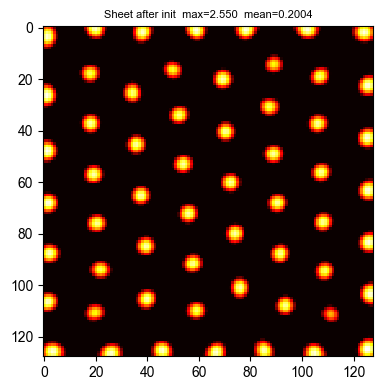

Init done.


In [10]:
r = np.zeros((N, N))

def _conv_aperiodic(r):
    """Zero-padded convolution — used during initialisation."""
    out = np.real(np.fft.ifft2(
        np.fft.fft2(r * typeR, (BIG, BIG)) * ftr_big +
        np.fft.fft2(r * typeL, (BIG, BIG)) * ftl_big +
        np.fft.fft2(r * typeD, (BIG, BIG)) * ftd_big +
        np.fft.fft2(r * typeU, (BIG, BIG)) * ftu_big
    ))
    return out[N//2 : BIG - N//2, N//2 : BIG - N//2]

def _conv_periodic(r):
    """Circular convolution — used during the main simulation."""
    return np.real(np.fft.ifft2(
        np.fft.fft2(r * typeR) * ftr_sm +
        np.fft.fft2(r * typeL) * ftl_sm +
        np.fft.fft2(r * typeD) * ftd_sm +
        np.fft.fft2(r * typeU) * ftu_sm
    ))

def _step(r, venv, right, left, up, down, vel, periodic):
    """Single dynamics step.  Eq. 1 and 4 of B&F 2009."""
    # Velocity-modulated feedforward input (Eq. 4)
    rfield = venv * (
        (1 + ALPHA * vel * right) * typeR +
        (1 + ALPHA * vel * left)  * typeL +
        (1 + ALPHA * vel * up)    * typeU +
        (1 + ALPHA * vel * down)  * typeD
    )
    rfield += _conv_periodic(r) if periodic else _conv_aperiodic(r)
    fr = np.maximum(rfield, 0)                            # rectification
    return np.minimum(10.0, r + (DT / TAU) * (5*fr - r)) # Eq. 1  (gain=5, clip=10)

print('Initialising (1000 steps, no velocity, aperiodic boundary)...')
for it in range(1000):
    venv = venv_ones if it >= 800 else venv_gauss
    r    = _step(r, venv, 0., 0., 0., 0., 0., periodic=False)
    if it % 250 == 249:
        print(f'  step {it+1}  mean={r.mean():.4f}  max={r.max():.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(r, cmap='hot', vmin=0, vmax=r.max(), interpolation='nearest')
ax.set_title(f'Sheet after init  max={r.max():.3f}  mean={r.mean():.4f}', fontsize=8)
plt.tight_layout(); plt.show()
print('Init done.')

## 4. Main simulation — gc_periodic.m lines 241–324

Exact velocity formula from the Matlab code:
```
vel   = speed per step
left  = -cos(theta_v),  right = cos(theta_v)
up    =  sin(theta_v),  down  = -sin(theta_v)
rfield = venv * ( (1 + alpha*vel*right)*typeR + ... )
```
Because `vel * cos(theta) = dx` and `vel * sin(theta) = dy`, this is equivalent to
passing the raw x/y displacement per step directly into the gain field.

In [11]:
# gc_periodic.m starts at increment=2 (1-indexed), so Python index 1
N_SIM    = N_TRAJ - 20   # gc_periodic.m: sampling_length - 20
STORE_N  = 20            # store every 20 steps (10 ms)
N_STORE  = N_SIM // STORE_N

# Neurons to record (including the paper's sNeuron = [N//2, N//2])
N_REC     = 48
rec_rows  = np.concatenate([[N//2], rng.integers(N//4, 3*N//4, N_REC-1)])
rec_cols  = np.concatenate([[N//2], rng.integers(N//4, 3*N//4, N_REC-1)])

rates_rec = np.zeros((N_REC, N_STORE), dtype=np.float32)
active_rec = np.zeros((N_REC, N_STORE), dtype=np.uint8)  # fr > 0 (paper's indicator)
pos_x_rec  = np.zeros(N_STORE)
pos_y_rec  = np.zeros(N_STORE)
store_ptr  = 0

snap_steps  = np.linspace(0, N_SIM-1, 8, dtype=int)
snap_frames = []

print(f'Running {N_SIM:,} steps ({N_SIM*DT/1000:.0f}s)...')
for it in range(N_SIM):
    inc = it + 1   # Matlab increment starts at 2 → Python index 1

    # Velocity — exact Matlab formula
    theta_v = head_dir[inc]
    vel     = vel_arr[inc]
    left    = -np.cos(theta_v)
    right   =  np.cos(theta_v)
    up      =  np.sin(theta_v)
    down    = -np.sin(theta_v)

    r = _step(r, venv_ones, right, left, up, down, vel, periodic=True)

    # Record
    if it % STORE_N == 0 and store_ptr < N_STORE:
        for ni in range(N_REC):
            rates_rec[ni, store_ptr]  = r[rec_rows[ni], rec_cols[ni]]
        pos_x_rec[store_ptr] = position_x[inc]
        pos_y_rec[store_ptr] = position_y[inc]
        store_ptr += 1

    if it in snap_steps:
        snap_frames.append(r.copy())

    if it % 10000 == 0:
        print(f'  {it}/{N_SIM}  mean={r.mean():.4f}  max={r.max():.3f}', end='\r')

print(f'\nDone.  Stored {store_ptr} time bins.')

Running 99,980 steps (50s)...
  90000/99980  mean=0.1668  max=2.472
Done.  Stored 4999 time bins.


## 5. Rate maps and bump snapshots

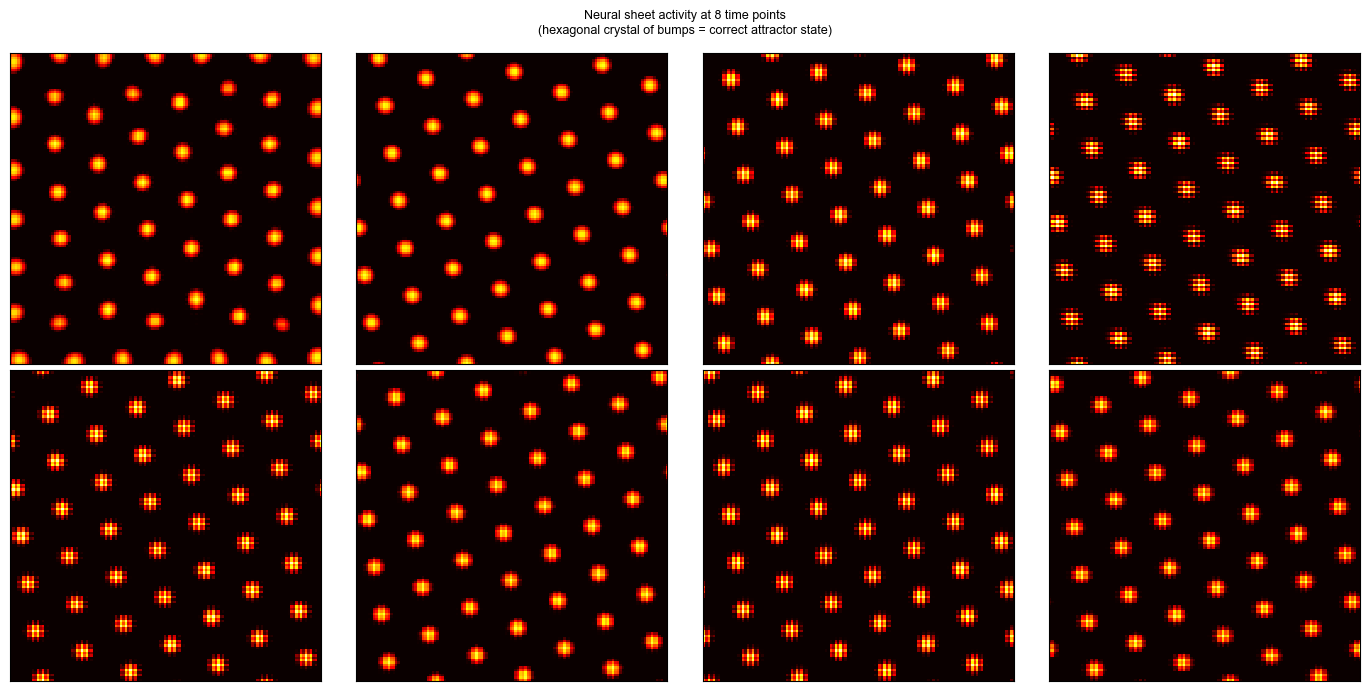

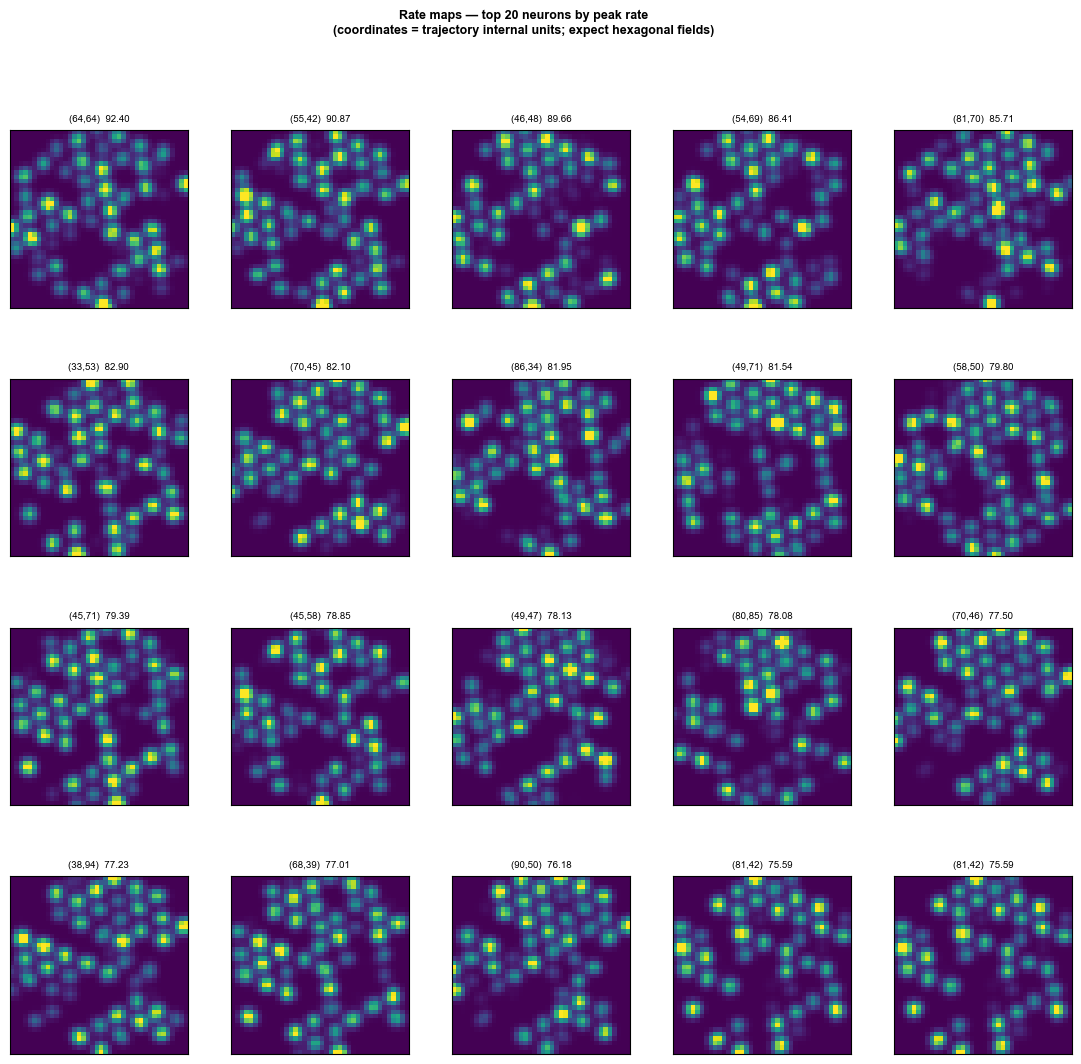

Bump/mean ratio (final frame): 16.3
Peak rate map value: 92.4049


In [12]:
# ── Bump snapshots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
vmax_s = max(f.max() for f in snap_frames)
for ax, frame in zip(axes.ravel(), snap_frames):
    ax.imshow(frame, cmap='hot', vmin=0, vmax=vmax_s, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Neural sheet activity at 8 time points\n'
             '(hexagonal crystal of bumps = correct attractor state)', fontsize=9)
plt.tight_layout(); plt.show()

# ── Rate maps in trajectory coordinates ───────────────────────────────────────
N_BINS = 40
xmin, xmax = position_x.min(), position_x.max()
ymin, ymax = position_y.min(), position_y.max()
edges_x = np.linspace(xmin, xmax, N_BINS + 1)
edges_y = np.linspace(ymin, ymax, N_BINS + 1)
DT_BIN  = STORE_N * DT / 1000   # bin width in seconds

def make_rate_map(rate_1d, px, py):
    tc,  _, _ = np.histogram2d(px, py, bins=[edges_x, edges_y],
                                weights=rate_1d.astype(float))
    occ, _, _ = np.histogram2d(px, py, bins=[edges_x, edges_y])
    rm = tc / np.where(occ * DT_BIN > 0, occ * DT_BIN, np.nan)
    return gaussian_filter(np.nan_to_num(rm).T, sigma=1.0)

rate_maps  = [make_rate_map(rates_rec[ni], pos_x_rec, pos_y_rec) for ni in range(N_REC)]
peak_rates = [rm.max() for rm in rate_maps]
top20      = np.argsort(peak_rates)[::-1][:20]

fig, axes = plt.subplots(4, 5, figsize=(14, 12),
                          gridspec_kw={'hspace':0.4, 'wspace':0.1})
for col, ni in enumerate(top20):
    row = col // 5; c = col % 5
    rm   = rate_maps[ni]
    vmax = np.nanpercentile(rm, 99)
    axes[row, c].imshow(rm, origin='lower', cmap='viridis',
                         vmin=0, vmax=max(vmax, 1e-3), interpolation='nearest')
    axes[row, c].set_xticks([]); axes[row, c].set_yticks([])
    axes[row, c].set_title(f'({rec_rows[ni]},{rec_cols[ni]})  {peak_rates[ni]:.2f}',
                            fontsize=7)
fig.suptitle('Rate maps — top 20 neurons by peak rate\n'
             '(coordinates = trajectory internal units; expect hexagonal fields)',
             fontsize=9, fontweight='bold')
plt.show()

print(f'Bump/mean ratio (final frame): {r.max()/r.mean():.1f}')
print(f'Peak rate map value: {max(peak_rates):.4f}')

## 6. Pairwise XGBoost — position + cell vs position only

In [ ]:
from spatial_manifolds.mlencoding import MLencoding

# Scale to spikes using rates (already in model units; scale to ~8 Hz)
MAX_RATE   = 8.0
r_max_all  = rates_rec.max()
rates_hz   = rates_rec * (MAX_RATE / (r_max_all + 1e-8))
spikes_rec = (rng.random(rates_rec.shape) < rates_hz * DT_BIN).astype(np.int8)
fr_rec     = spikes_rec.sum(axis=1) / (N_SIM * DT / 1000)

N_XGB   = 20
top_idx = np.argsort(fr_rec)[::-1][:N_XGB]
print(f'Top {N_XGB}  FR: {fr_rec[top_idx].min():.2f}–{fr_rec[top_idx].max():.2f} Hz')

# Normalise positions to [0, 1]
pos_x_n = (pos_x_rec - xmin) / (xmax - xmin + 1e-8)
pos_y_n = (pos_y_rec - ymin) / (ymax - ymin + 1e-8)
x_pos   = np.column_stack([pos_x_n, pos_y_n])
spk_top = spikes_rec[top_idx].astype(float)

BIN_MS = int(STORE_N * DT)   # 10 ms bins
xgb = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                  window=BIN_MS, n_filters=5, max_time=100)

pr2_mat = np.full((N_XGB, N_XGB), np.nan)
for ti in range(N_XGB):
    y = spk_top[ti]
    _, pr2_pos = xgb.fit_cv(x_pos, y, verbose=0, continuous_folds=True, n_cv=5)
    pr2_pos_m  = float(np.nanmean(pr2_pos))
    for ci in range(N_XGB):
        if ci == ti: continue
        x_full = np.column_stack([x_pos, spk_top[ci]])
        _, pr2_full = xgb.fit_cv(x_full, y, verbose=0, continuous_folds=True, n_cv=5)
        pr2_mat[ci, ti] = float(np.nanmean(pr2_full)) - pr2_pos_m
    print(f'  target {ti}/{N_XGB-1}', end='\r')

print(f'\nMax Δpρ² (above pos) = {np.nanmax(pr2_mat):.4f}')

## 7. Comparison figure

In [ ]:
# Rate-map correlation as ground truth proxy
rm_top   = np.array([rate_maps[i] for i in top_idx])
rm_flat  = rm_top.reshape(N_XGB, -1).astype(float)
rm_flat -= rm_flat.mean(axis=1, keepdims=True)
rm_norm  = rm_flat / (np.linalg.norm(rm_flat, axis=1, keepdims=True) + 1e-8)
map_corr = rm_norm @ rm_norm.T

fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35, left=0.05, right=0.97)

ax = fig.add_subplot(gs[0])
im = ax.imshow(map_corr, cmap='RdBu_r', vmin=-1, vmax=1,
               aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.04).set_label('Pearson r', fontsize=7)
ax.set_title('Rate-map correlation\n(ground truth)', fontsize=8, fontweight='bold')
ax.set_xlabel('Neuron'); ax.set_ylabel('Neuron')

ax = fig.add_subplot(gs[1])
vmax_pr2 = max(np.nanpercentile(pr2_mat, 98), 1e-5)
im = ax.imshow(pr2_mat, cmap='hot', vmin=0, vmax=vmax_pr2,
               aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.04).set_label('Δpρ²', fontsize=7)
ax.set_title('XGBoost Δpρ²\n(above position)', fontsize=8, fontweight='bold')
ax.set_xlabel('Target')

ax = fig.add_subplot(gs[2])
mask  = ~np.eye(N_XGB, dtype=bool)
xsc   = map_corr[mask]
ysc   = pr2_mat[mask]
valid = ~np.isnan(ysc)
ax.scatter(xsc[valid], ysc[valid], s=12, alpha=0.5, color='#444')
if valid.sum() > 2:
    r_c = np.corrcoef(xsc[valid], ysc[valid])[0, 1]
    ax.set_title(f'Map corr vs Δpρ²\nr = {r_c:.2f}', fontsize=8)
ax.axhline(0, color='grey', lw=0.7, ls='--')
ax.axvline(0, color='grey', lw=0.7, ls='--')
ax.set_xlabel('Rate-map correlation', fontsize=8)
ax.set_ylabel('Δpρ² above position', fontsize=8)
ax.spines[['top','right']].set_visible(False)

# Example rate maps
ax = fig.add_subplot(gs[3])
ax.axis('off')
for ki in range(4):
    ni  = top_idx[ki]
    rm  = rate_maps[ni]
    sub = fig.add_axes([0.79+(ki%2)*0.093, 0.55-(ki//2)*0.38, 0.085, 0.32])
    sub.imshow(rm, origin='lower', cmap='viridis', vmin=0, vmax=rm.max(),
               interpolation='nearest')
    sub.set_xticks([]); sub.set_yticks([])
    sub.set_title(f'N{ni}', fontsize=7)

fig.suptitle('B&F CAN (exact reproduction) — emergent grid cells\n'
             'Δpρ² = pρ²(position + cell) − pρ²(position only)',
             fontsize=10, fontweight='bold')
fig.savefig(fig_path + 'synthetic_full_can_validation.pdf', bbox_inches='tight', dpi=200)
plt.show()
print('Saved.')